# Long recurrences: particles 1 and 3

**Question:** after how many forcing cycles does the numerical Poincare sequence nearly repeat, and does the same long recurrence persist throughout the record?

Use only the original **particle IDs 1 and 3** from the saved **BM4Implicit** run: **5,000 forcing cycles, 40 complete integration steps per cycle**. The analysis reads the checksum-verified cycle CSV and original initial states; it performs no new trajectory integration. Execute the notebook in the project Python environment.

The default search covers **1–1,000 cycles**, retaining short lags as controls and requiring at least five candidate-period lengths in the full record. All 5,001 positions per particle are retained, including the initial state. The source physics, numerical settings and editable analysis controls are explicit below.

These are approximate recurrences of once-per-cycle numerical samples. A distant close return or a small repetition defect does not by itself establish an exact physical periodic orbit. No independently audited reference covers the full 5,000-cycle interval; the standard reference ending at normalized time 35 cannot validate this record.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from diagnostics.paths import find_project_root
from diagnostics.poincare_periodicity import export_poincare_periodicity
from studies.poincare_periodicity import (
    load_saved_poincare_section, analyze_poincare_periodicity,
    periodicity_interpretation,
)
from visualization.poincare_periodicity import (
    export_interval_recurrence_viewer, plot_section_initial_positions,
    plot_periodicity_diagnostic, show_periodicity_figure,
)

PROJECT = find_project_root(Path.cwd())
STUDY = PROJECT / 'notebooks/developements/poincare_section/Poincare_BM4Implicit_24_impares_5000_ciclos_40_steps_spot'
RUN_ID = 'aws_bm4implicit_24odd_5000c_40s_20260920'
PARTICLE_IDS = (1, 3)

# Immutable source-run physics and numerics; changing these requires matching saved data.
CYCLES = 5000
STEPS_PER_CYCLE = 40
CYCLE_DURATION = 1.0
T0 = 0.0
RHO = 0.3
COUPLING_FREQUENCY = np.pi / 8
RADIAL_FRACTIONS = (0.0, 0.020851063829787235)
RADIAL_ANGLE_RAD = 0.0
B_TESLA = 1.5
CHARACTERISTIC_LENGTH_M = 0.06
SOURCE_SELECTION = (0, 1)
INTERPOLATION_ORDER = 3
FIELD_SHA256 = '4bbd873cd05992e0a615d66ebbf4d96b38c8b3c36be2ca62932e66af7e6d4ced'
NEWTON_ATOL = 1e-12
NEWTON_RTOL = 1e-11
NEWTON_MAX_CORRECTIONS = 40
JACOBIAN_RELATIVE_STEP = np.cbrt(np.finfo(float).eps)

# Editable analysis controls; no random sampling or seed is used.
# Scan all integer lags, including short controls, to identify long recurrences.
MAX_LAG = 1000
MINIMUM_REPETITIONS = 5
THRESHOLDS_OVER_L = (1e-5, 5e-5, 1e-4, 5e-4, 1e-3)
SAVE_PRODUCTS = True
FIGURES = STUDY / 'figuras' / RUN_ID / 'long_periodicity_particles_1_3'
DIAGNOSTICS = STUDY / 'resultados' / RUN_ID / 'long_periodicity_particles_1_3'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

Verified source: aws_bm4implicit_24odd_5000c_40s_20260920; L=18.8495559215; integration step=0.025
Forcing cycle: 0.00261352184253 s; coordinate unit: 0.00954929658551 m
Potential: PHI_2.h5; SHA256: 4bbd873cd05992e0a615d66ebbf4d96b38c8b3c36be2ca62932e66af7e6d4ced
Selected initial states (coordinates and spatial radii divided by L):


,particle,x_over_L,y_over_L,radius_over_L,color
0,1,0.500000,0.5,0.000000,#372466
1,3,0.520851,0.5,0.020851,#4040a2


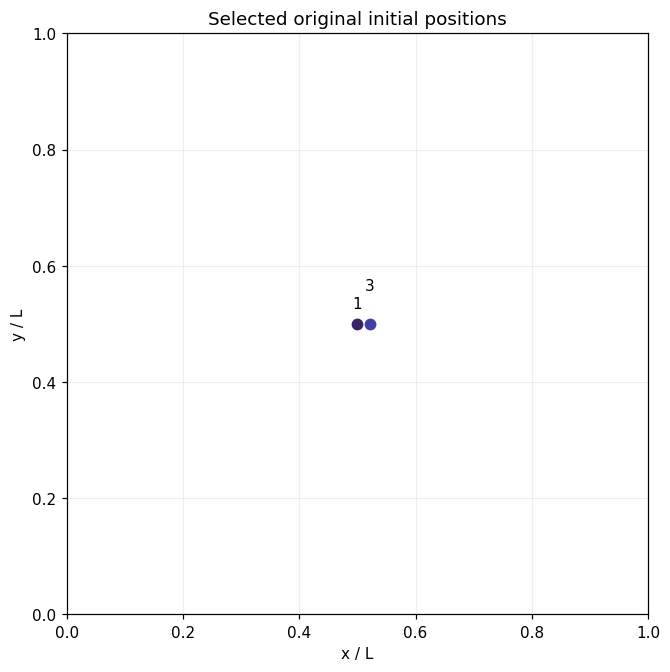

In [2]:
section = load_saved_poincare_section(STUDY, RUN_ID, PARTICLE_IDS)
meta = section.metadata
field = meta['field_provenance']
L = field['grid']['period']
assert meta['method'] == 'BM4Implicit' and meta['arithmetic'] == 'float64'
assert section.positions.shape == (CYCLES + 1, len(PARTICLE_IDS), 2)
assert meta['cycles'] == CYCLES and meta['steps_per_cycle'] == STEPS_PER_CYCLE
assert meta['complete_steps'] == CYCLES * STEPS_PER_CYCLE
assert meta['newton_max_iterations'] == NEWTON_MAX_CORRECTIONS
assert meta['newton_jacobian'] == 'analytic' and meta['nonlinear_solver'] == 'newton'
assert tuple(field['source_selection']) == SOURCE_SELECTION
assert field['interpolation_order'] == INTERPOLATION_ORDER
assert field['source_hdf5_sha256'] == FIELD_SHA256
np.testing.assert_allclose(
    [meta['rho'], meta['coupling_frequency'], meta['radial_angle_rad'], meta['t0'],
     meta['cycle_duration'], meta['step'], meta['newton_atol'], meta['newton_rtol'],
     meta['jacobian_relative_step'], field['B_tesla'], field['characteristic_length_m']],
    [RHO, COUPLING_FREQUENCY, RADIAL_ANGLE_RAD, T0, CYCLE_DURATION,
     CYCLE_DURATION / STEPS_PER_CYCLE, NEWTON_ATOL, NEWTON_RTOL,
     JACOBIAN_RELATIVE_STEP, B_TESLA, CHARACTERISTIC_LENGTH_M], rtol=1e-14, atol=0,
)
np.testing.assert_allclose(meta['t_span'], [T0, T0 + CYCLES * CYCLE_DURATION])
np.testing.assert_allclose([r['radius_over_L'] for r in section.initial_records], RADIAL_FRACTIONS)
print(f"Verified source: {RUN_ID}; L={L:.12g}; integration step={meta['step']:g}")
print(f"Forcing cycle: {meta['time_scale_s']:.12g} s; coordinate unit: {meta['length_scale_m']:.12g} m")
print('Potential: PHI_2.h5; SHA256:', FIELD_SHA256)
print('Selected initial states (coordinates and spatial radii divided by L):')
display(pd.DataFrame(section.initial_records))
show_periodicity_figure(plot_section_initial_positions(section),
                        FIGURES if SAVE_PRODUCTS else None, 'initial_positions')

## Long-lag repetition test

Let $z_n=(x_n/L,y_n/L)$ be the saved position at forcing cycle $n$. For each integer lag $q$, evaluate

$$d_q(n)=\left\|\operatorname{wrap}_{[-1/2,1/2)}(z_{n+q}-z_n)\right\|_2,\qquad n=0,\ldots,N-q.$$

The best candidate minimizes the **RMS defect over every overlapping pair**. The maximum and 95th percentile show whether a small RMS hides poorly repeated portions. A return to the initial position alone does not select the candidate. The spatial norm uses the minimum-image convention in the periodic cell and is expressed as a fraction of $L$.

The effective upper lag is $\min(\mathrm{MAX\_LAG},\lfloor N/\mathrm{MINIMUM\_REPETITIONS}\rfloor)$. With the default controls it is 1,000 cycles; five period lengths do not mean five statistically independent repetitions because the pairs overlap. To explore beyond 1,000 cycles, explicitly increase `MAX_LAG` and reduce `MINIMUM_REPETITIONS` to 3 or 4. Three is the supported minimum and allows at most 1,666 cycles for this record. Longer candidates need more saved cycles.

The first and second halves are also evaluated separately, using only pairs contained in their respective windows. Agreement between their preferred lags is a temporal stability diagnostic. It is not an independent statistical confirmation of a candidate selected from the complete record.

In [3]:
analysis = analyze_poincare_periodicity(
    section.positions, PARTICLE_IDS, max_lag=MAX_LAG,
    minimum_repetitions=MINIMUM_REPETITIONS,
    threshold_fractions=THRESHOLDS_OVER_L,
)
assert tuple(row['particle'] for row in analysis.summary) == PARTICLE_IDS
assert analysis.lags[-1] == min(MAX_LAG, CYCLES // MINIMUM_REPETITIONS)
assert analysis.metrics.shape == (len(analysis.lags), len(PARTICLE_IDS), 5)
summary = pd.DataFrame(analysis.summary).set_index('particle')
print(f'Searched integer lags: {analysis.lags[0]} to {analysis.lags[-1]} forcing cycles')
display(summary[['best_q', 'rms_over_L', 'p95_over_L', 'max_over_L',
                 'overlap_pairs', 'record_repetitions']])
print('Ranked local minima, including the search endpoints as controls:')
display(pd.DataFrame(analysis.candidates).set_index(['particle', 'q']))

Searched integer lags: 1 to 1000 forcing cycles


,best_q,rms_over_L,p95_over_L,max_over_L,overlap_pairs,record_repetitions
particle,,,,,,
1,149,0.000086,0.000141,0.000177,4852,33.557047
3,835,0.000031,0.000046,0.000053,4166,5.988024


Ranked local minima, including the search endpoints as controls:


rms_over_L  max_over_L
particle q                          
1        149    0.000086    0.000177
         298    0.000173    0.000351
         447    0.000259    0.000525
         596    0.000346    0.000692
         745    0.000432    0.000857
         894    0.000519    0.001013
         996    0.000525    0.001019
         847    0.000612    0.001173
         698    0.000699    0.001319
         549    0.000785    0.001462
3        835    0.000031    0.000053
         904    0.000057    0.000099
         69     0.000088    0.000152
         766    0.000118    0.000204
         973    0.000145    0.000250
         138    0.000175    0.000303
         697    0.000206    0.000355
         207    0.000263    0.000453
         628    0.000294    0.000506
         276    0.000351    0.000603

## Full saved Poincare sections

Color every saved return by forcing cycle to inspect how each section is populated over time. The red cross is the verified original initial position. The geometric shape alone does not determine a period.

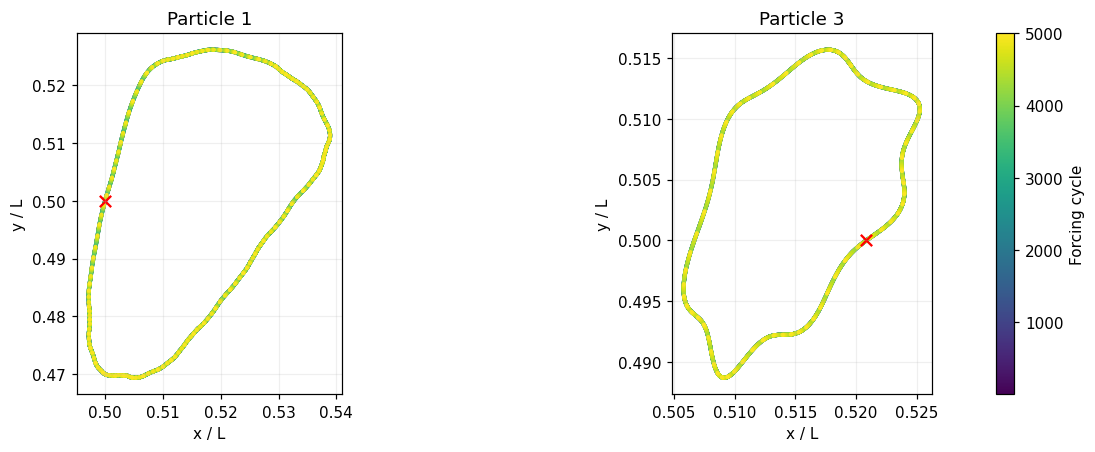

In [4]:
show_periodicity_figure(
    plot_periodicity_diagnostic(section, analysis, diagnostic='sections'),
    FIGURES if SAVE_PRODUCTS else None, 'poincare_sections',
)

## Search for long recurrences

Compare the RMS and maximum defects over the entire searched lag interval. The marked lag is computed from the record rather than supplied as a hypothesis. Deep minima identify good approximate recurrences; further minima may be harmonics or rational approximations to a noninteger rhythm. A candidate at the upper search boundary merits an extended record or search before interpretation.

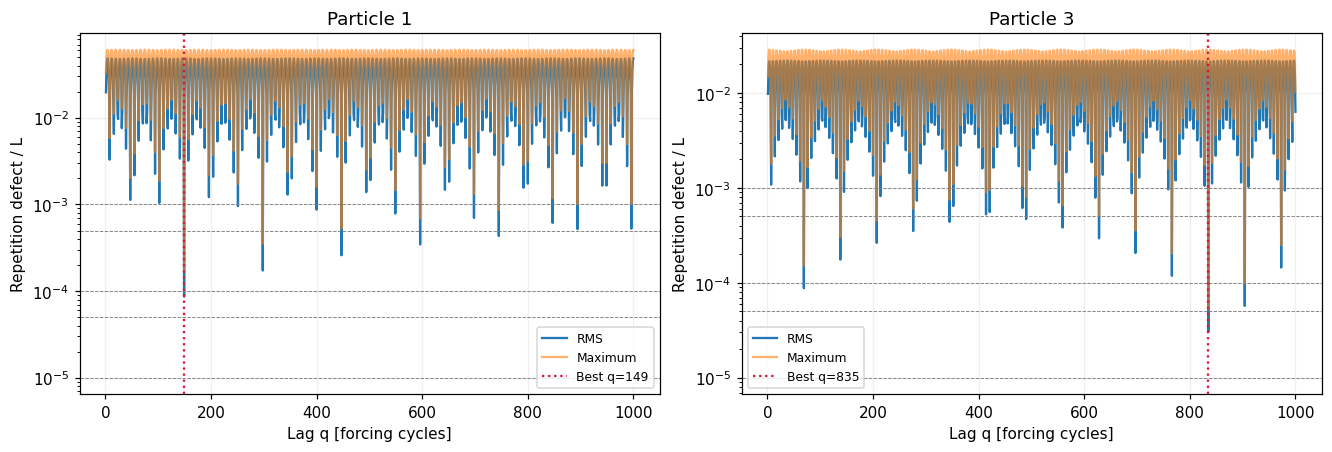

In [5]:
show_periodicity_figure(
    plot_periodicity_diagnostic(section, analysis, diagnostic='lag_scan'),
    FIGURES if SAVE_PRODUCTS else None, 'long_lag_scan',
)

## Stability between the two halves

`first_half_rms` and `second_half_rms` evaluate the **same full-record best lag** in each window. The two `*_best_q` columns independently minimize each half's RMS over the same lag range. A change in preferred lag or defect size can indicate slow drift or modulation. For large lags each half contains fewer candidate-period lengths than the complete record.

,best_q,first_half_best_q,second_half_best_q,first_half_rms,second_half_rms
particle,,,,,
1,149,149,149,0.000085,0.000088
3,835,835,835,0.000031,0.000031


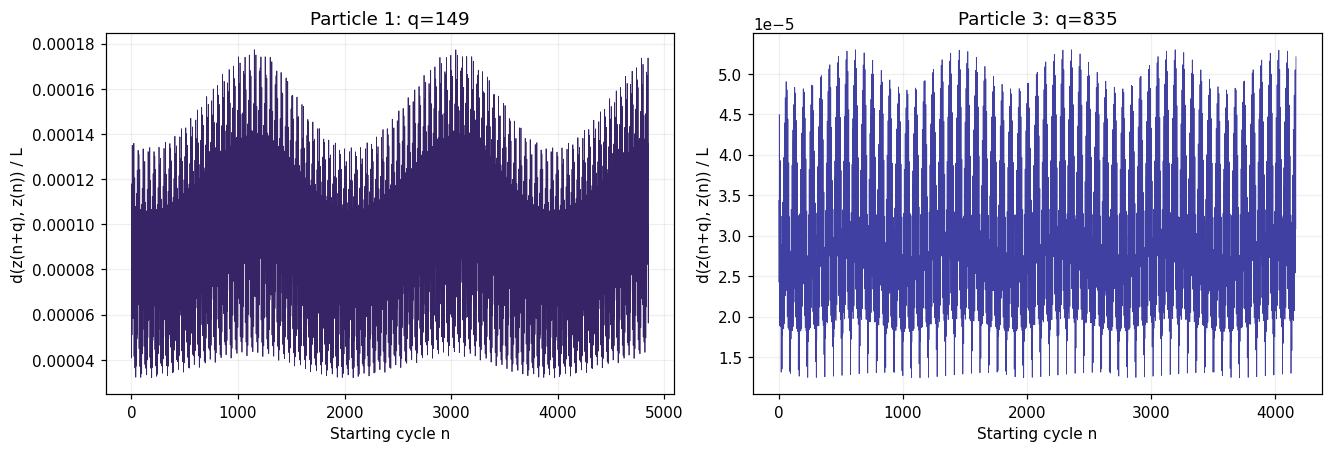

In [6]:
display(summary[['best_q', 'first_half_best_q', 'second_half_best_q',
                 'first_half_rms', 'second_half_rms']])
show_periodicity_figure(
    plot_periodicity_diagnostic(section, analysis, diagnostic='best_history'),
    FIGURES if SAVE_PRODUCTS else None, 'best_lag_defect_history',
)

## Interactive evolution in space and initial-state distance

Open the generated self-contained HTML viewer in a new browser tab. Particle 1 is shown above particle 3. Each row combines the spatial Poincare returns with the distance to the particle's verified initial state.

The shared **start cycle** and **end cycle** controls update both representations at once. The spatial panel contains exactly one saved return per selected cycle, while the graph is restricted to the same interval. The status reports the number of returns per particle and the total number of spatial points currently displayed.

In [7]:
from IPython.display import FileLink, IFrame

INTERVAL_VIEWER_HTML = FIGURES / 'interactive_space_and_initial_returns.html'
export_interval_recurrence_viewer(
    INTERVAL_VIEWER_HTML, section, analysis,
    title='Particles 1 and 3: spatial evolution and initial-state returns',
)
display(FileLink(
    str(INTERVAL_VIEWER_HTML),
    result_html_prefix='Open the interactive interval viewer in a new tab: ',
))
display(IFrame(str(INTERVAL_VIEWER_HTML), width='100%', height=1500))

/home/juagil@cartif.local/Investigaciones/GC2D/GC2D_codigo/notebooks/developements/poincare_section/Poincare_BM4Implicit_24_impares_5000_ciclos_40_steps_spot/figuras/aws_bm4implicit_24odd_5000c_40s_20260920/long_periodicity_particles_1_3/interactive_space_and_initial_returns.html

## Spectral context: a short rhythm can produce a long recurrence

The spectrum sums the power of the four smooth periodic observables $\sin(2\pi x/L)$, $\sin(2\pi y/L)$, $\cos(2\pi x/L)$ and $\cos(2\pi y/L)$. A Hann window and mean removal are used. The initial sample is excluded, and the two half-record spectra use disjoint samples. Frequencies are measured in inverse forcing cycles; sampling is once per cycle.

The reciprocal of the strongest nonzero-frequency bin is a dominant oscillation timescale, **not the long recurrence period**. A near-commensurate short oscillation can produce a much longer good integer-cycle return. Finite spectral resolution and sampling prevent an exact periodicity claim from a narrow peak alone.

,best_q,peak_frequency,oscillation_cycles,first_half_frequency,second_half_frequency
particle,,,,,
1,149,0.1276,7.836991,0.1276,0.1276
3,835,0.1450,6.896552,0.1448,0.1448


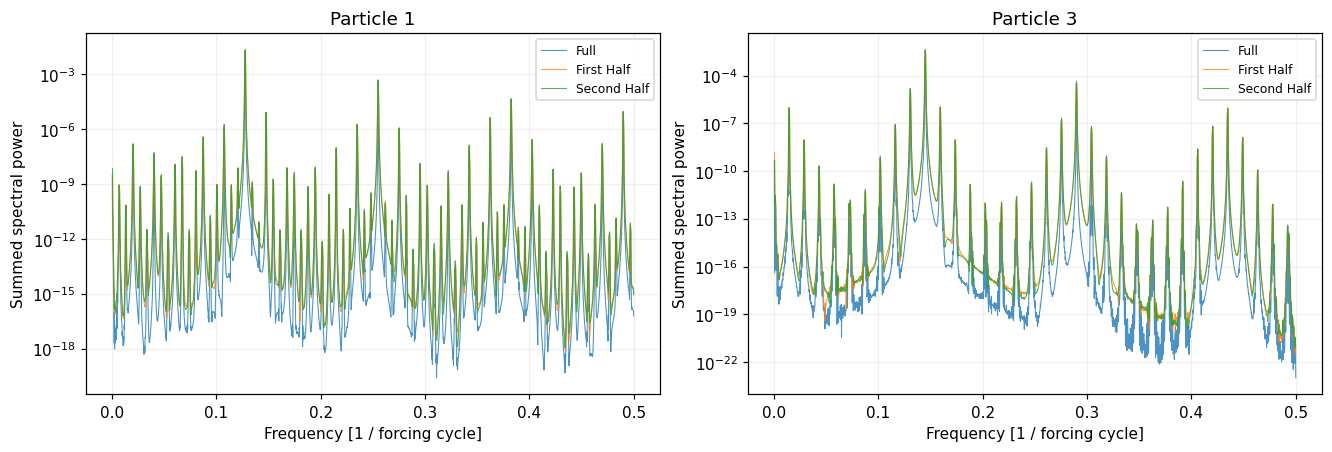

In [8]:
display(summary[['best_q', 'peak_frequency', 'oscillation_cycles',
                 'first_half_frequency', 'second_half_frequency']])
show_periodicity_figure(
    plot_periodicity_diagnostic(section, analysis, diagnostic='spectra'),
    FIGURES if SAVE_PRODUCTS else None, 'spectral_context',
)

## How close is the repetition?

For each explicitly chosen geometric threshold, report the **smallest tested lag whose maximum defect** stays below that threshold over every available pair. A missing value means no tested lag passes. This criterion is stricter than minimizing the RMS. Thresholds are fractions of the cell period; they are neither solver tolerances nor estimates of trajectory uncertainty.

In [9]:
thresholds = pd.DataFrame(analysis.thresholds)
display(thresholds.pivot(index='particle', columns='threshold_over_L', values='smallest_q')
        .astype('Int64'))

threshold_over_L,0.00001,0.00005,0.00010,0.00050,0.00100
particle,,,,,
1,<NA>,<NA>,<NA>,149,149
3,<NA>,<NA>,835,69,69


## Computed interpretation and reproducible exports

Read the preferred long lags together with their worst defects and half-record stability. Stable approximate recurrence can coexist with a noninteger short rhythm and accumulated phase drift. Neither a successful geometric threshold nor its failure classifies the underlying physical motion by itself.

With `SAVE_PRODUCTS = True`, save the full lag scan, candidate and threshold tables, initial states, source hashes, controls and computed interpretation in `long_periodicity_particles_1_3` under the original run's diagnostics directory. Figures go to the corresponding new figure directory. This notebook analyzes saved data from one method, so the multi-method accuracy and runtime comparison protocol is outside its scope.

In [10]:
interpretation = periodicity_interpretation(analysis)
display(Markdown(interpretation))
if SAVE_PRODUCTS:
    controls = dict(
        max_lag=MAX_LAG, minimum_repetitions=MINIMUM_REPETITIONS,
        thresholds_over_L=THRESHOLDS_OVER_L,
        candidate_selection='Minimum RMS over all overlapping pairs at integer lags',
        stability_windows='First and second half; no distance pair crosses the split',
        observables='sin/cos of 2*pi*x/L and 2*pi*y/L',
        spectral_window='Hann; record means removed; initial sample excluded',
        sample_rate_per_forcing_cycle=1.0,
    )
    export_poincare_periodicity(
        DIAGNOSTICS, section, analysis, controls=controls, interpretation=interpretation,
    )
    print('Long-recurrence tables and source provenance:', DIAGNOSTICS)
    print('Figures:', FIGURES)

- **Particle 1:** best approximate lag **149 cycles**; RMS 8.64033e-05 L; maximum 0.000177311 L. Dominant spectral timescale: 7.83699 cycles. smallest q=149 at 0.0005 L; smallest q=149 at 0.001 L
- **Particle 3:** best approximate lag **835 cycles**; RMS 3.06239e-05 L; maximum 5.29622e-05 L. Dominant spectral timescale: 6.89655 cycles. smallest q=835 at 0.0001 L; smallest q=69 at 0.0005 L; smallest q=69 at 0.001 L

These are finite-record diagnostics of saved numerical Poincare returns. A passing geometric threshold does not certify an exact physical period. Failure does not prove chaos or exclude a period beyond the searched range. Full within-cycle repetition and independently audited trajectory accuracy are not tested.

Long-recurrence tables and source provenance: /home/juagil@cartif.local/Investigaciones/GC2D/GC2D_codigo/notebooks/developements/poincare_section/Poincare_BM4Implicit_24_impares_5000_ciclos_40_steps_spot/resultados/aws_bm4implicit_24odd_5000c_40s_20260920/long_periodicity_particles_1_3
Figures: /home/juagil@cartif.local/Investigaciones/GC2D/GC2D_codigo/notebooks/developements/poincare_section/Poincare_BM4Implicit_24_impares_5000_ciclos_40_steps_spot/figuras/aws_bm4implicit_24odd_5000c_40s_20260920/long_periodicity_particles_1_3
